# 층화 샘플링

- 머신러닝 프로젝트의 일부 섹션으로 추가되어야 함. 
- 파머 펭귄 데이터셋에 대해.

**기본 설정**

탐색적 데이터분석(EDA)에 필요한 핵심 라이브러리를 불러온다.

- `numpy`: 수치 연산
- `pandas`: 데이터프레임 기반 데이터 처리
- `matplotlib.pyplot`: 데이터 시각화
- `seaborn`: 통계 기반 데이터 시각화

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

데이터프레임 내 부동소수점을 소수점 이하 6자리까지만 출력하도록 지정한다.

In [2]:
pd.set_option('display.precision', 6)

**데이터 저장소**

In [3]:
data_url = 'https://raw.githubusercontent.com/codingalzi/code-workout-datasci/refs/heads/master/data/'

`pd.read_csv()` 함수를 사용하여 CSV 파일을 데이터프레임으로 불러온다.

In [4]:
housing = pd.read_csv(data_url+'housing.csv')

### 결측치 확인

앞서 `info()`를 통해 `total_bedrooms` 열에 결측치가 있음을 확인했다.
이상치를 제거한 후의 결측치 수를 `isnull().sum()`으로 다시 확인한다.

In [5]:
housing.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [7]:
mask = housing['total_bedrooms'].isnull()
housing[mask].shape

(207, 10)

### 결측치 처리

결측치를 처리하는 대표적인 방법은 세 가지이다.

| 방법 | 설명 | 사용 시점 |
| :--- | :--- | :--- |
| **삭제** | 결측치가 있는 행을 제거 | 결측치가 매우 적을 때 |
| **대체** | 평균, 중위수 등으로 채움 | 결측치가 적당할 때 |
| **예측** | 다른 특성으로 결측치를 추정 | 결측치가 많고 패턴이 있을 때 |

여기서는 `total_bedrooms` 열의 **중위수**(median)로 결측치를 채우는 방법을 사용한다.
중위수는 이상치에 덜 민감하므로 평균보다 안정적인 대체값이 된다.

In [8]:
median = housing["total_bedrooms"].median()
housing.loc[:, "total_bedrooms"] = housing.loc[:, "total_bedrooms"].fillna(median)

In [9]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20640 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


## 전체 데이터와 층화 표본 비교

현실에서는 항상 전체 데이터를 모두 분석할 수 있는 것은 아니다. 따라서 잘 추출된 표본이 전체 데이터의 분포와 관계를 어느 정도 보존하는지 확인하는 일이 중요하다. 여기서는 중위소득(median_income) 구간을 기준으로 층화 표본을 만들고, 전체 데이터와 표본의 주요 통계 지표와 그래프를 비교한다.

### 가구소득 구간 만들기

층화 샘플링의 기준으로 사용할 가구소득 구간을 만든다. 중위소득은 주택가격과 비교적 강한 양의 상관관계를 보였으므로, 주택가격을 탐색할 때 중요한 층화 기준으로 사용할 수 있다.

In [10]:
housing_for_sampling = housing.copy()

housing_for_sampling['income_cat'] = pd.cut(
    housing_for_sampling['median_income'],
    bins=[0., 1.5, 3.0, 4.5, 6.0, np.inf],
    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
)

housing_for_sampling[['median_income', 'median_house_value', 'income_cat']].head()

,median_income,median_house_value,income_cat
0,8.3252,452600.0,Very High
1,8.3014,358500.0,Very High
2,7.2574,352100.0,Very High
3,5.6431,341300.0,High
4,3.8462,342200.0,Medium


### 층화 샘플링

각 가구소득 구간에서 같은 비율로 데이터를 추출한다. 여기서는 그래프 비교가 너무 성기지 않도록 전체의 10%를 표본으로 사용한다.

In [11]:
stratified_sample = (
    housing_for_sampling
    .groupby('income_cat', observed=True, group_keys=False)
    .sample(frac=0.1, random_state=42)
)

stratified_sample.shape

(2064, 11)

### 가구소득 구간 비율 비교

먼저 층화 기준으로 사용한 가구소득 구간의 비율이 전체 데이터와 표본에서 비슷하게 유지되는지 확인한다.

In [12]:
income_proportions = pd.concat(
    [
        housing_for_sampling['income_cat'].value_counts(normalize=True).sort_index(),
        stratified_sample['income_cat'].value_counts(normalize=True).sort_index()
    ],
    axis=1
)

income_proportions.columns = ['Full Data', '층화 표본']
income_proportions

,Full Data,층화 표본
income_cat,,
Very Low,0.039826,0.039729
Low,0.318847,0.318798
Medium,0.350581,0.350775
High,0.176308,0.176357
Very High,0.114438,0.114341


c:\Users\gslee\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52789 (\N{HANGUL SYLLABLE CEUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\gslee\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\gslee\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\gslee\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


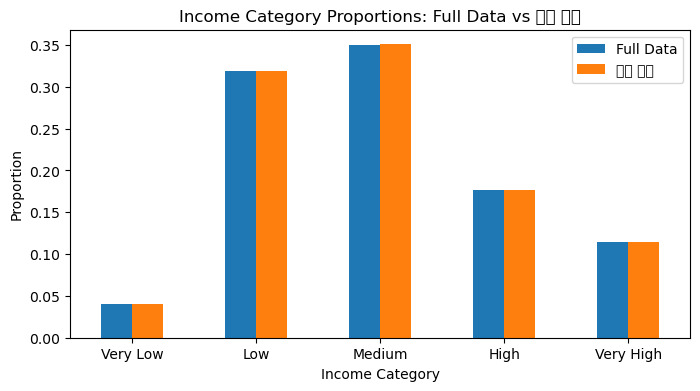

In [13]:
income_proportions.plot(kind='bar', figsize=(8, 4))
plt.title('Income Category Proportions: Full Data vs 층화 표본')
plt.xlabel('Income Category')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.show()

막대그래프의 높이가 거의 비슷하다면, 층화 표본이 가구소득 구간별 비율을 잘 유지하고 있다고 볼 수 있다. 이는 표본이 전체 데이터의 중요한 구조를 어느 정도 보존한다는 첫 번째 단서다.

### 주요 변수의 분포 비교

이번에는 중위소득과 중위 주택가격의 분포 모양을 비교한다. 표본이 전체 데이터를 잘 대표한다면, 히스토그램의 전체적인 모양도 크게 다르지 않아야 한다.

C:\Users\gslee\AppData\Local\Temp\ipykernel_19736\2094940297.py:17: UserWarning: Glyph 52789 (\N{HANGUL SYLLABLE CEUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\gslee\AppData\Local\Temp\ipykernel_19736\2094940297.py:17: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\gslee\AppData\Local\Temp\ipykernel_19736\2094940297.py:17: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\gslee\AppData\Local\Temp\ipykernel_19736\2094940297.py:17: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\gslee\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52789 (\N{HANGUL SYLLABLE CEUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\gslee\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54

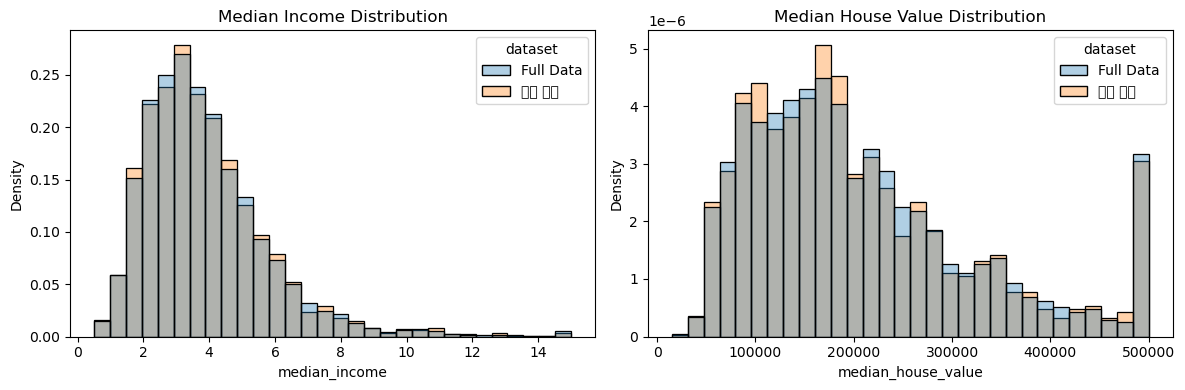

In [14]:
comparison_df = pd.concat(
    [
        housing_for_sampling.assign(dataset='Full Data'),
        stratified_sample.assign(dataset='층화 표본')
    ],
    ignore_index=True
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=comparison_df, x='median_income', hue='dataset', bins=30, stat='density', common_norm=False, alpha=0.35, ax=axes[0])
axes[0].set_title('Median Income Distribution')

sns.histplot(data=comparison_df, x='median_house_value', hue='dataset', bins=30, stat='density', common_norm=False, alpha=0.35, ax=axes[1])
axes[1].set_title('Median House Value Distribution')

plt.tight_layout()
plt.show()

### 주택가격의 중심과 퍼짐 비교

상자그림은 중앙값, 사분위수, 이상치의 차이를 빠르게 비교할 때 유용하다. 전체 데이터와 층화 표본의 상자그림이 비슷하다면, 표본이 주택가격의 중심과 퍼짐도 비교적 잘 보존한다고 해석할 수 있다.

c:\Users\gslee\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52789 (\N{HANGUL SYLLABLE CEUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\gslee\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\gslee\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\gslee\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


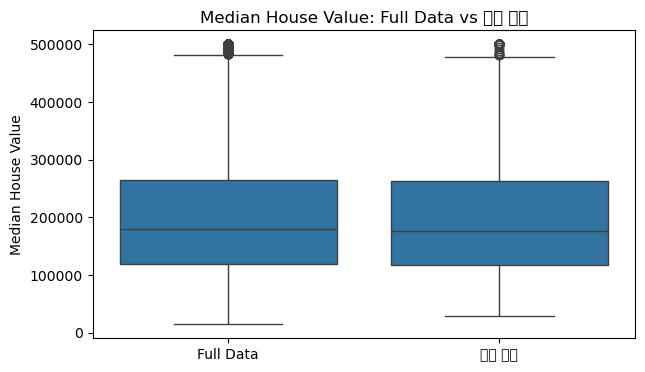

In [15]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=comparison_df, x='dataset', y='median_house_value')
plt.title('Median House Value: Full Data vs 층화 표본')
plt.xlabel('')
plt.ylabel('Median House Value')
plt.show()

### 중위소득과 주택가격의 관계 비교

마지막으로 중위소득과 주택가격의 관계가 표본에서도 유지되는지 산점도로 확인한다. 전체 데이터와 표본 모두에서 오른쪽 위로 향하는 경향이 보이면, 주요 상관관계가 표본에서도 비슷하게 나타난다고 볼 수 있다.

C:\Users\gslee\AppData\Local\Temp\ipykernel_19736\3507378992.py:9: UserWarning: Glyph 52789 (\N{HANGUL SYLLABLE CEUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\gslee\AppData\Local\Temp\ipykernel_19736\3507378992.py:9: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\gslee\AppData\Local\Temp\ipykernel_19736\3507378992.py:9: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\gslee\AppData\Local\Temp\ipykernel_19736\3507378992.py:9: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\gslee\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52789 (\N{HANGUL SYLLABLE CEUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\gslee\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54868 

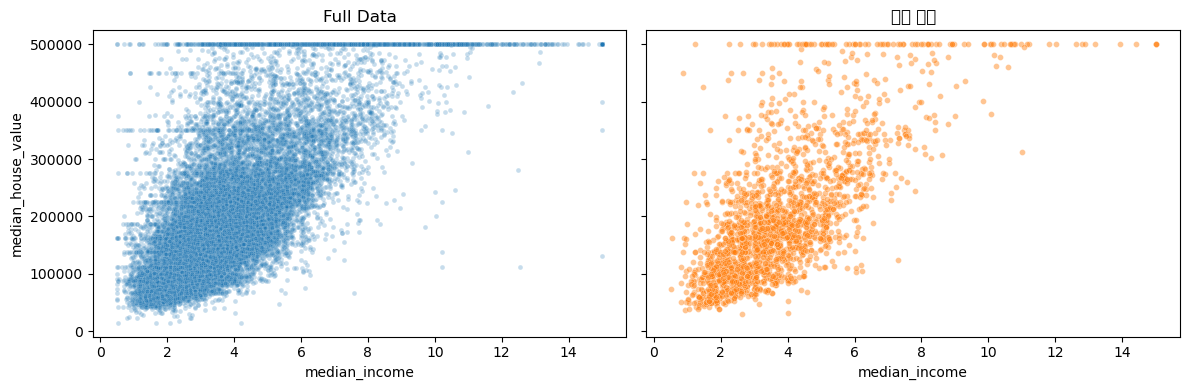

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)

sns.scatterplot(data=housing_for_sampling, x='median_income', y='median_house_value', alpha=0.25, s=12, ax=axes[0])
axes[0].set_title('Full Data')

sns.scatterplot(data=stratified_sample, x='median_income', y='median_house_value', alpha=0.45, s=18, ax=axes[1], color='tab:orange')
axes[1].set_title('층화 표본')

plt.tight_layout()
plt.show()

### 통계 지표 비교

그래프로 확인한 내용을 숫자로도 비교한다. 평균, 중앙값, 표준편차, 상관계수가 전체 데이터와 표본에서 얼마나 비슷한지 살펴보자.

In [17]:
features = ['median_income', 'median_house_value']

summary_comparison = pd.concat(
    {
        'Full Data': housing_for_sampling[features].agg(['mean', 'median', 'std']),
        '층화 표본': stratified_sample[features].agg(['mean', 'median', 'std'])
    },
    axis=1
)

summary_comparison

Full Data                            층화 표본                   
       median_income median_house_value median_income median_house_value
mean        3.870671      206855.816909      3.861760      204847.090116
median      3.534800      179700.000000      3.521700      177350.000000
std         1.899822      115395.615874      1.880149      115491.326769

In [18]:
corr_comparison = pd.DataFrame(
    {
        'Full Data': [housing_for_sampling[features].corr().loc['median_income', 'median_house_value']],
        '층화 표본': [stratified_sample[features].corr().loc['median_income', 'median_house_value']]
    },
    index=['median_income과 median_house_value의 상관계수']
)

corr_comparison

,Full Data,층화 표본
median_income과 median_house_value의 상관계수,0.688075,0.689549


### 해석

층화 표본은 전체 데이터와 비교했을 때 가구소득 구간별 비율을 잘 유지한다. 또한 중위소득과 주택가격의 분포, 주택가격의 중심과 퍼짐, 두 변수 사이의 양의 상관관계도 전체 데이터와 크게 다르지 않게 나타난다.

따라서 이번 예제에서는 가구소득을 기준으로 만든 층화 표본이 전체 데이터의 주요 EDA 결과를 비교적 잘 보존한다고 볼 수 있다. 다만 이것이 모든 표본에 항상 성립하는 것은 아니다. 표본의 크기, 층화 기준, 데이터의 수집 방식에 따라 결과가 달라질 수 있으므로, EDA에서는 그래프와 통계량뿐 아니라 표본이 전체를 잘 대표하는지도 함께 확인해야 한다.